## FINANCIAL FRAUD DETECTION AND TRANSACTION ANALYSIS 


## objective
- What percentage of transactions are fraudulent?
- Which transaction type has the highest fraud rate?
- Which transaction type processes the highest transaction amount?
- Are high-value transactions more likely to be fraudulent?
- How do account balances change during fraudulent transactions?
- What is the total financial impact of fraud?
- Which transaction categories contribute most to fraud losses?
- What patterns distinguish fraudulent transactions from normal transactions?
- How is transaction volume distributed across transaction types?
- What factors can help identify suspicious transactions?

In [1]:
pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234",
    database="fraud_analysis"
)

df = pd.read_sql("SELECT * FROM Fraud_Transaction", conn)
df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_10424\961389552.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM Fraud_Transaction", conn)


,Transaction_Step,Transaction_Type,Transaction_Amount,Sender_Name,Before_Balance,New_balance,Receiver_id,Receiver_Balance_Before,Receiver_Balance_After,Is_Fraud,Is_Flagged_Fraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:

df.head(2)

,Transaction_Step,Transaction_Type,Transaction_Amount,Sender_Name,Before_Balance,New_balance,Receiver_id,Receiver_Balance_Before,Receiver_Balance_After,Is_Fraud,Is_Flagged_Fraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0


In [5]:
df.columns

Index(['Transaction_Step', 'Transaction_Type', 'Transaction_Amount',
       'Sender_Name', 'Before_Balance', 'New_balance', 'Receiver_id',
       'Receiver_Balance_Before', 'Receiver_Balance_After', 'Is_Fraud',
       'Is_Flagged_Fraud'],
      dtype='str')

In [6]:
#1. What percentage of transactions are fraudulent?
Fraud_Percentage = df['Is_Fraud'].sum()/len(df)*100
print("Fraud_Percentage:", round(Fraud_Percentage, 4), "%")

Fraud_Percentage: 0.0843 %


## Insight
 - Total fraud percentage is 0.843%.
 - This indicates that fraud cases represent only a very small portion of the overall transactions.

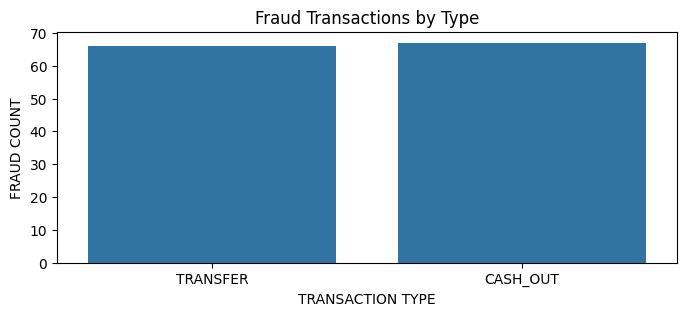

In [7]:
#2. Which transaction type has the highest fraud rate?
plt.figure(figsize=(8,3))
sns.countplot(x='Transaction_Type',data=df[df['Is_Fraud']==1])
plt.title("Fraud Transactions by Type")
plt.xlabel("TRANSACTION TYPE")
plt.ylabel("FRAUD COUNT")
plt.show()

## Insight
- CASH_OUT has the highest fraud rate compared to other transaction types.
- Although TRANSFER and CASH_OUT have a very small difference in fraud rates,
  this shows that both have a higher fraud risk
- This indicates that fraud is more common in CASH_OUT and TRANSFER
  transactions than in other transaction categories.

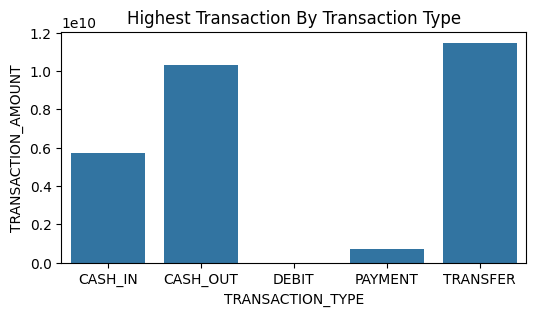

In [8]:
#3. Which transaction type processes the highest transaction amount?

Amount_sum =df.groupby('Transaction_Type').agg({'Transaction_Amount':'sum'}).reset_index()
plt.figure(figsize=(6,3))
sns.barplot( x= 'Transaction_Type',y = 'Transaction_Amount',data=Amount_sum)
plt.xlabel ("TRANSACTION_TYPE")
plt.ylabel ("TRANSACTION_AMOUNT")
plt.title("Highest Transaction By Transaction Type")
plt.show()

## Insight
- TRANSFER processes the highest transaction amount compared to other transaction types.
- This indicates that TRANSFER is the most frequently used transaction type for handling large-value transactions.
- Although CASH_OUT ranks second in terms of transaction amount, this shows that CASH_OUT is also commonly used for    transactions.

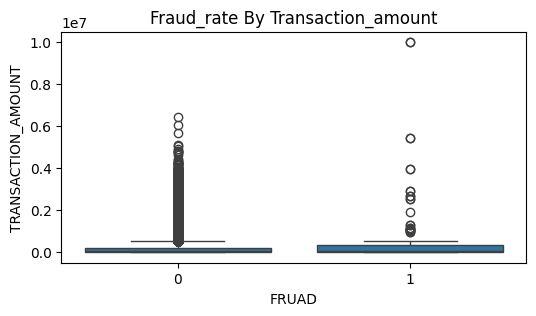

In [9]:
#4. Are high-value transactions more likely to be fraudulent?

plt.figure(figsize=(6,3))
sns.boxplot(x= 'Is_Fraud',y = 'Transaction_Amount',data =df)
plt.xlabel('FRUAD')
plt.ylabel('TRANSACTION_AMOUNT')
plt.title("Fraud_rate By Transaction_amount")
plt.show()

## Insight
- High Values transaction are More Likely To be fraudulent.
- Fraudulent transactions generally involve higher transaction amounts compared to non-fraudulent transactions.
- This indicates large value Transactions Have Higher Fraud rate than Low Value transactions.

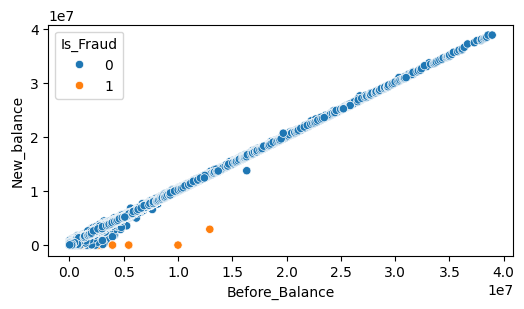

In [10]:
#5. How do account balances change during fraudulent transactions?

plt.figure(figsize=(6,3))
sns.scatterplot(x ='Before_Balance',y ='New_balance',data = df,hue = 'Is_Fraud')
plt.show()

## Insight
- Non-fraudulent transactions follow a consistent balance pattern between Before_Balance and New_balance.
- Fraudulent transactions show irregular balance changes and do not follow the normal balance trend.
- This indicates that unusual changes in account balance may be linked to fraud.

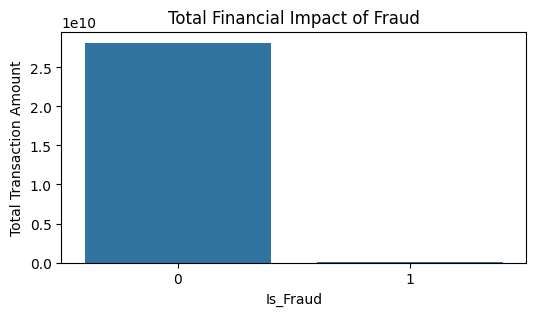

   Is_Fraud  Transaction_Amount
0         0        2.816670e+10
1         1        8.080738e+07


In [27]:
#6. What is the total financial impact of fraud?
impact = df.groupby('Is_Fraud').agg({'Transaction_Amount':'sum'}).reset_index()
plt.figure(figsize=(6,3))
sns.barplot(x= 'Is_Fraud',y='Transaction_Amount',data=impact)
plt.title("Total Financial Impact of Fraud")
plt.xlabel("Is_Fraud")
plt.ylabel("Total Transaction Amount")
plt.show()
print(impact)

## Insight
- The total financial transaction amount is approximately 28.16 billion.
- Out of this, the fraudulent transaction amount is around 80.8 million, which is very small in comparison.
- This indicates that fraud represents a very small portion of total transactions, but still results in a significant financial loss.

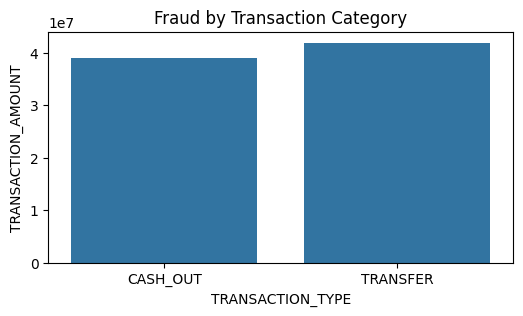

In [12]:
#7. Which transaction categories contribute most to fraud losses?
fraud_data =df[df['Is_Fraud']==1]
dd =fraud_data.groupby('Transaction_Type').agg({'Transaction_Amount':'sum'}).reset_index()
plt.figure(figsize=(6,3))
sns.barplot(x='Transaction_Type',y='Transaction_Amount',data=dd)
plt.xlabel('TRANSACTION_TYPE')
plt.ylabel('TRANSACTION_AMOUNT')
plt.title("Fraud by Transaction Category")
plt.show()

## Insight
- TRANSFER contributes the highest fraud losses compared to other transaction types.
- CASH_OUT ranks second in terms of fraud losses, indicating that both TRANSFER and CASH_OUT are major contributors to fraud.
- This suggests that fraud is more common in high-value transaction types, especially TRANSFER and CASH_OUT transactions.

In [ ]:
# 8.What patterns distinguish fraudulent transactions from normal transactions? 

# Insight
- The total fraud percentage is 0.843%.
- CASH_OUT has the highest fraud rate compared to other transaction types.
- TRANSFER processes the highest transaction amount compared to other transaction types.
- High-value transactions are more likely to be fraudulent.
- Non-fraudulent transactions follow a consistent balance pattern between Before_Balance and New_balance, while fraudulent  transactions show irregular balance changes and do not follow the normal trend.
- The total financial transaction amount is approximately 28.16 billion, out of which the fraudulent amount is around 80.8
 million, which is very small in comparison.
- TRANSFER contributes the highest fraud losses compared to other transaction types.

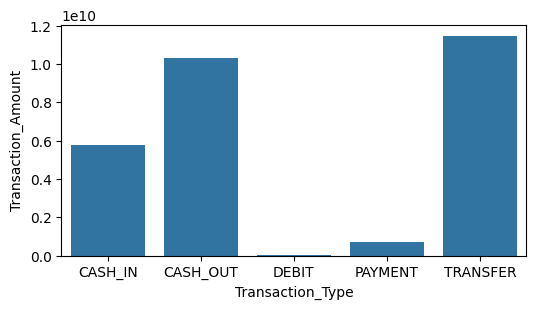

In [13]:
#9. How is transaction volume distributed across transaction types?
dd = df.groupby('Transaction_Type').agg({'Transaction_Amount':'sum'}).reset_index()
plt.figure(figsize=(6,3))
sns.barplot(x='Transaction_Type',y='Transaction_Amount',data=dd)
plt.show()

## Insight
- TRANSFER is the highest transaction type in terms of transaction volume.
- CASH_OUT ranks second in terms of total transaction amount.
- CASH_IN ranks third, while PAYMENT and DEBIT have the lowest transaction amounts.
- This indicates that TRANSFER and CASH_OUT are mainly used for high-value transactions, whereas PAYMENT and DEBIT are generally used for low-value transactions.

In [ ]:
#10. What factors can help identify suspicious transactions?

## Insight
- TRANSACTION AMOUNT helps in identifying suspicious transactions, as higher transaction values are more likely to be associated with fraud.
- TRANSACTION TYPE is also important, where TRANSFER and CASH_OUT are commonly linked with higher-value and fraudulent activities.
- BANK ACCOUNT BALANCE behavior helps detect fraud, especially irregular or sudden changes in Before_Balance and New_balance.
- Overall, TRANSACTION AMOUNT, TRANSACTION TYPE, and BANK ACCOUNT BALANCE patterns are key factors in identifying suspicious transactions.


## Final Conclusion
- The Total fraud percentage is 0.843%.
- CASH_OUT has the highest fraud rate compared to other transaction type.
- TRANSFER processes the highest transaction amount compared to other transaction types.
- High-value transactions are more likely to be fraudulent.
- The total financial transaction amount is approximately 28.16 billion, out of which the fraudulent amount is around 80.8 million, which is very small in comparison.
- TRANSFER contributes the highest fraud losses compared to other transaction types.
- Account balance behavior helps in detecting fraud, especially irregular or sudden changes in Before_Balance and New_balance.

## Overall Insight
Overall, Transaction Amount, Transaction Type, and Account Balance patterns are the key factors in identifying suspicious transactions.